In [1]:
import numpy as np
import pandas as pd
import zarr
import os
from tqdm import tqdm
from pathlib import Path

####################################################
# Configuration (Example)
# You should change these paths to your data location
FILE_PATH = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

# ROI coordinates (in pixels)

scale = 0.11

width_um = 5
height_um = 5

ROI = (1000, 1000, int(width_um/scale), int(height_um/scale))  # (x_start, y_start, width, height)
####################################################

path = Path(FILE_PATH)

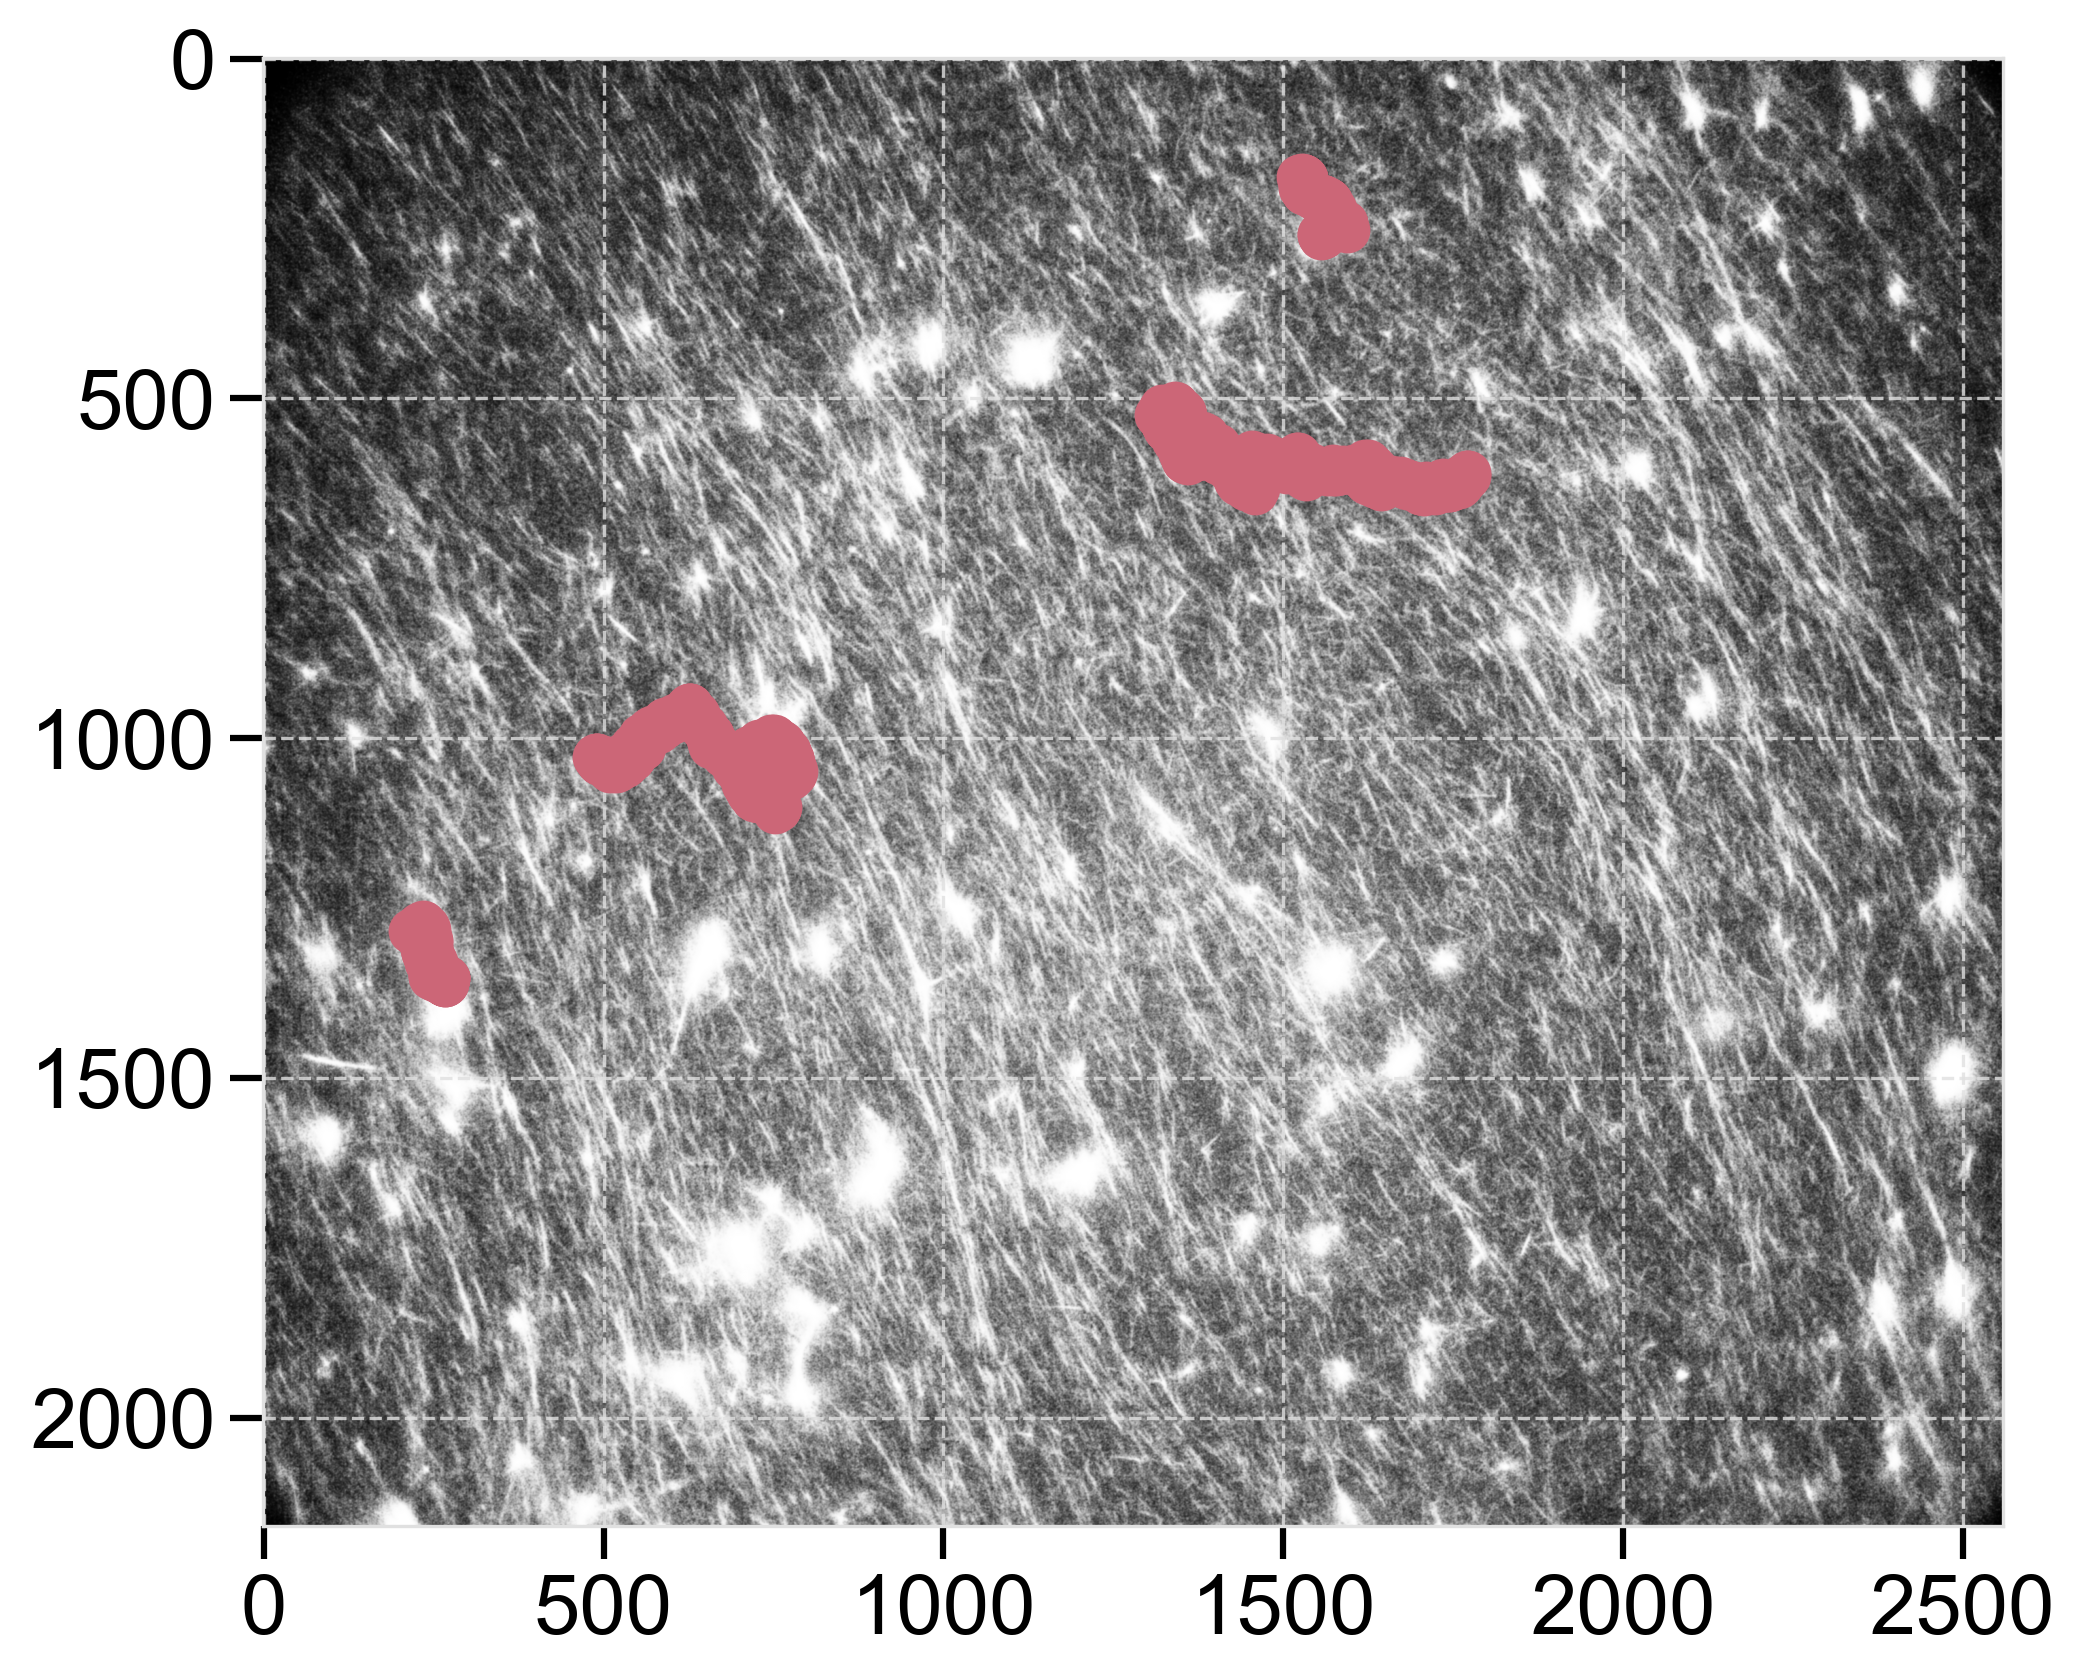

In [2]:
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

track = pd.read_csv( path / 'beads_tracks.csv')
img = zarr.open(path/'MTs.zarr', mode='r')

x, y = track['x'].to_numpy(), track['y'].to_numpy()

plt.imshow(img[0], cmap='gray')
plt.scatter(x, y)

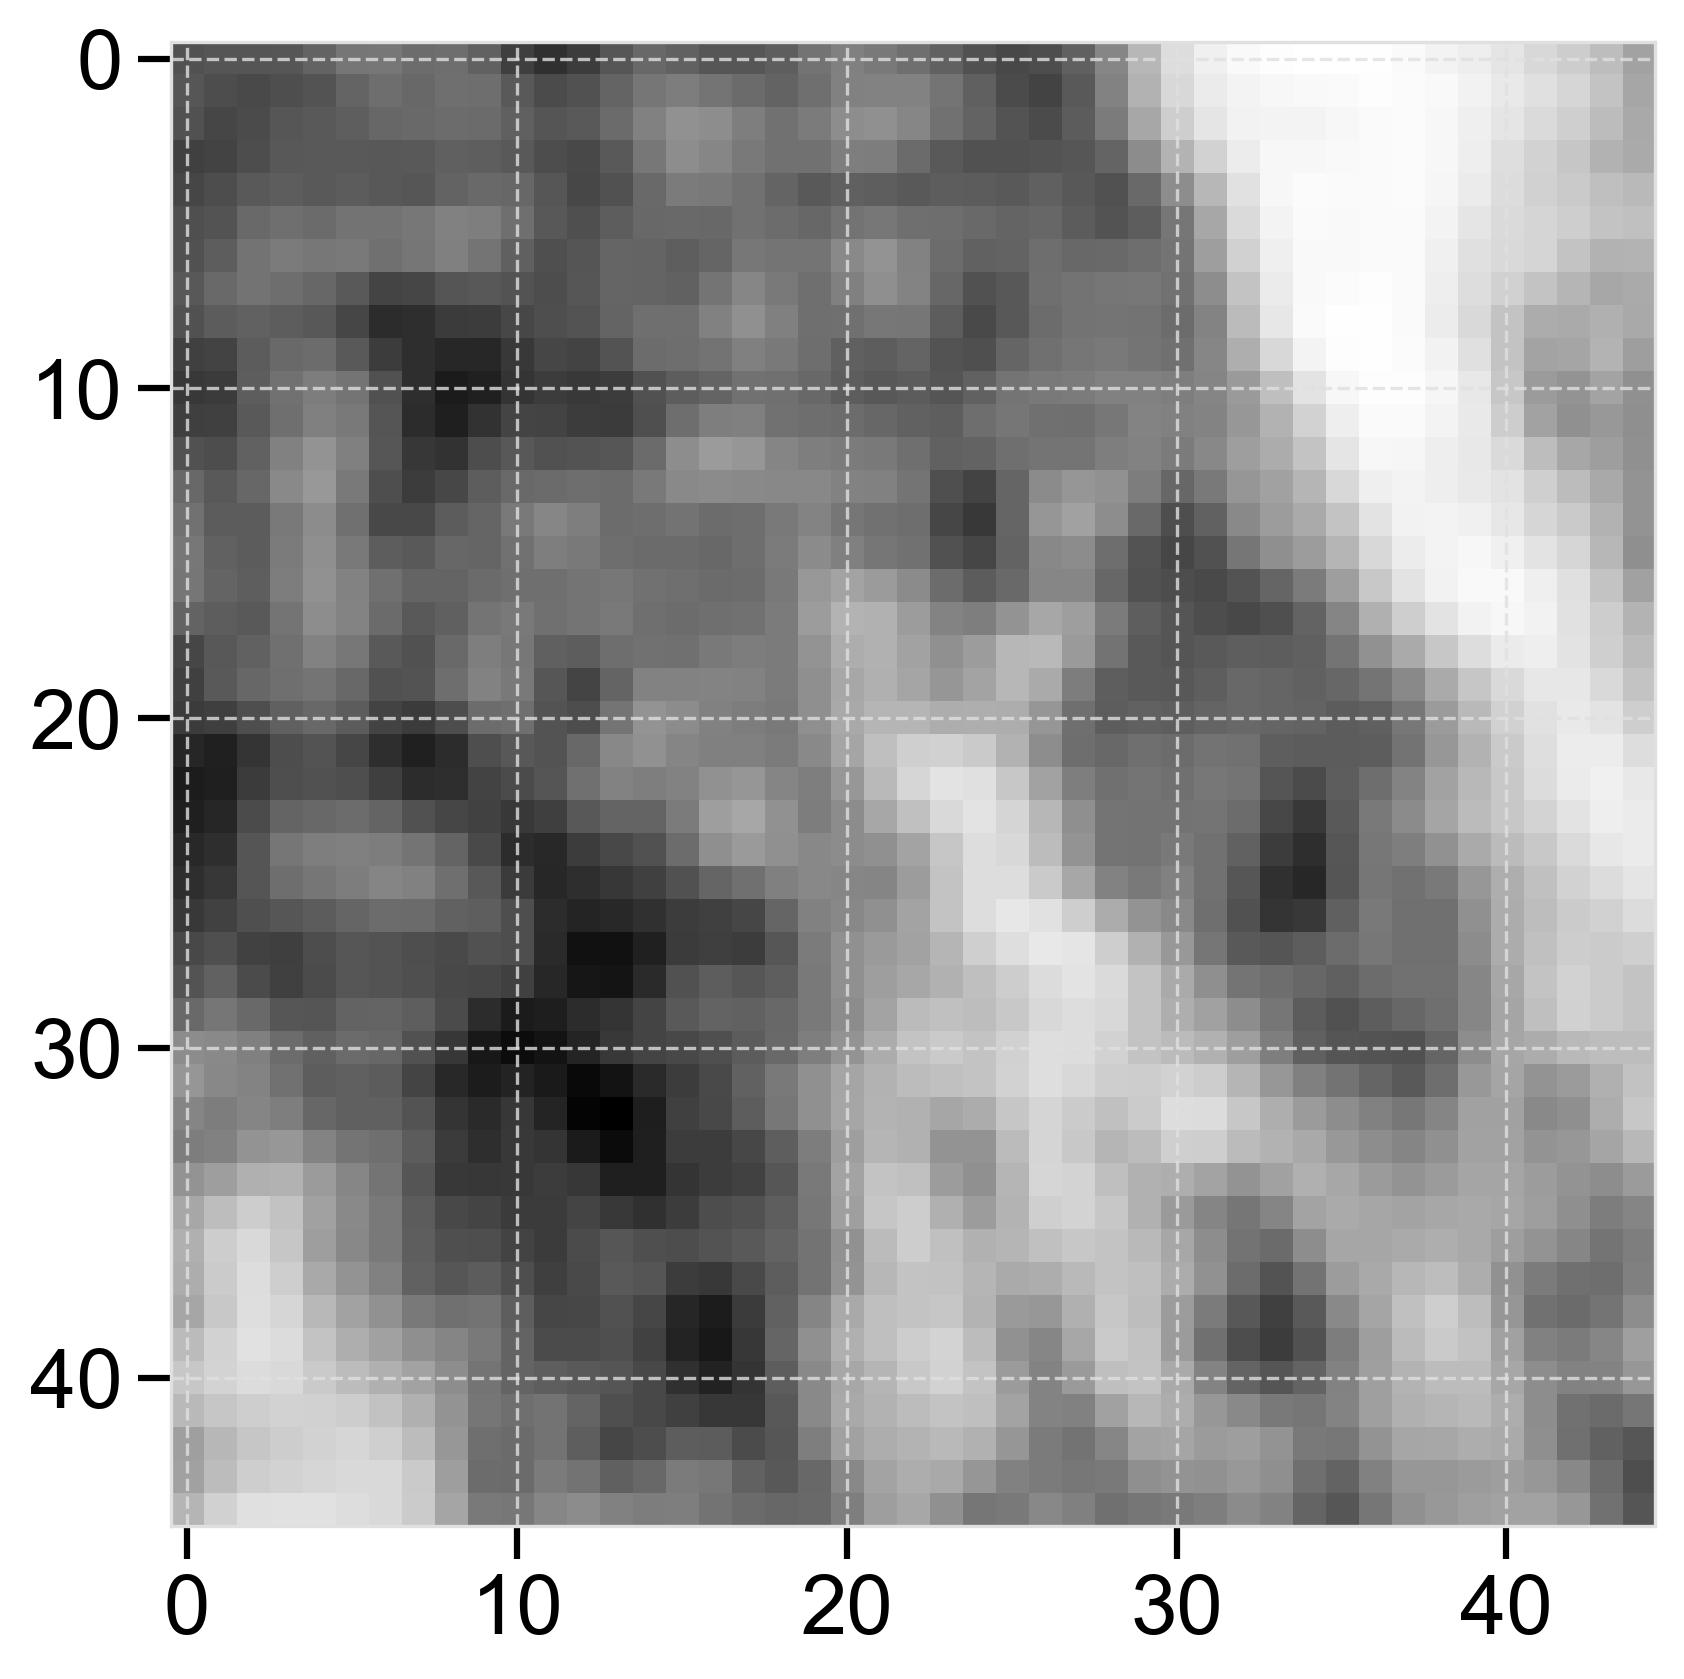

In [3]:
mask = (ROI[0]<x)&(x<ROI[0]+ROI[2]) & (ROI[1]<y)&(y<ROI[1]+ROI[3])

plt.imshow(img[0, ROI[0]:ROI[0]+ROI[2], ROI[1]:ROI[1]+ROI[3]], cmap='gray')
plt.scatter(x[mask]-ROI[0], y[mask]-ROI[1])

In [4]:
def calculate_polar_roi(flow_array, x_start, y_start, width, height):
    """
    Calculate the polar order parameter for a specific rectangular region of interest (ROI).
    
    Args:
        flow_array: Optical flow array (zarr or numpy), shape (T, H, W, 2)
        x_start: x-coordinate of the top-left corner of the ROI
        y_start: y-coordinate of the top-left corner of the ROI
        width: width of the ROI
        height: height of the ROI
        
    Returns:
        Ps: numpy array of shape (T,) containing the polar order parameter for each frame.
    """
    
    # Image dimensions
    if isinstance(flow_array, list):
        num_frames = len(flow_array) + 1 # Assuming flow is T-1
        max_h, max_w = flow_array[0].shape[0], flow_array[0].shape[1]
    else:
        num_frames = flow_array.shape[0] + 1
        max_h, max_w = flow_array.shape[1], flow_array.shape[2]
        
    Ps = np.full(num_frames, np.nan)
    
    # Define ROI slice
    # Ensure ROI is within bounds
    x_end = min(x_start + width, max_w)
    y_end = min(y_start + height, max_h)
    x_start = max(0, x_start)
    y_start = max(0, y_start)
    
    if x_start >= x_end or y_start >= y_end:
        print("Warning: ROI is outside of image bounds or invalid.")
        return Ps

    print(f"Processing {num_frames-1} frames for ROI: x=[{x_start}:{x_
                                                                    end}], y=[{y_start}:{y_end}]...")
    
    # Loop over frames
    # Flow array usually has T-1 frames compared to original video
    # Assuming flow_array[t] corresponds to flow between frame t and t+1 (or t-1 and t)
    # Consistent with previous scripts: frames usually start at 1 for flow
    
    for t in tqdm(range(num_frames - 1)):
        try:
            current_flow = flow_array[t]
            
            # Extract ROI
            roi_flow = current_flow[y_start:y_end, x_start:x_end, :]
            
            # Calculate P for this ROI
            u = roi_flow[..., 0]
            v = roi_flow[..., 1]
            
            magnitude = np.sqrt(u**2 + v**2)
            
            # Mean calculation over the ROI
            mean_u = np.mean(u)
            mean_v = np.mean(v)
            
            mean_mag_vectors = np.mean(magnitude)
            mag_mean_vector = np.sqrt(mean_u**2 + mean_v**2)
            
            if mean_mag_vectors == 0:
                P_val = np.nan
            else:
                P_val = mag_mean_vector / mean_mag_vectors
                
            # Store result
            # Assuming flow index t corresponds to frame t+1 or t. 
            # In previous scripts, flow_array[t-1] was used for frame t.
            # So flow_array[0] corresponds to frame 1.
            Ps[t+1] = P_val
            
        except IndexError:
            break
            
    print("Calculation complete.")
    return Ps

 
print(f"Loading data from {FILE_PATH}...")

# Check if paths exist
if os.path.exists(FILE_PATH):
    flow_path = os.path.join(FILE_PATH, "green_flow.zarr")
    
    if os.path.exists(flow_path):
        try:
            flow_array = zarr.open_array(flow_path, mode='r')
            
            x_s, y_s, w, h = ROI
            print(f"Calculating polar order parameter for ROI: x={x_s}, y={y_s}, w={w}, h={h}")
            
            Ps = calculate_polar_roi(flow_array, x_s, y_s, w, h)

            # Save to CSV
            output_path = os.path.join(FILE_PATH, f"roi_polar_x{x_s}_y{y_s}_w{w}_h{h}.csv")
            df = pd.DataFrame({'frame': np.arange(len(Ps)), 'P': Ps})
            df.to_csv(output_path, index=False)
            
            print(f"Saved ROI polar parameters to {output_path}")
            
        except Exception as e:
            print(f"An error occurred: {e}")
    else:
        print(f"Flow file not found: {flow_path}")
else:
    print(f"Directory not found: {FILE_PATH}")


Loading data from /Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002...
Calculating polar order parameter for ROI: x=1000, y=1000, w=45, h=45
Processing 1001 frames for ROI: x=[1000:1045], y=[1000:1045]...


100%|██████████| 1001/1001 [55:36<00:00,  3.33s/it]

Calculation complete.
Saved ROI polar parameters to /Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/roi_polar_x1000_y1000_w45_h45.csv
